# Image Classification using CNN

## Objective

Image Classification is the process of assigning labels to images based on their visual content.

This project uses:

- Deep Learning
- Convolutional Neural Networks (CNN)
- TensorFlow/Keras

Dataset:
- CIFAR-10

Classes:
- Airplane
- Automobile
- Bird
- Cat
- Deer
- Dog
- Frog
- Horse
- Ship
- Truck

In [6]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

## Load CIFAR-10 Dataset

In [7]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Training Images :", X_train.shape)

print("Testing Images :", X_test.shape)

Training Images : (50000, 32, 32, 3)
Testing Images : (10000, 32, 32, 3)


## Class Names

In [8]:
class_names = [
    'Airplane',
    'Automobile',
    'Bird',
    'Cat',
    'Deer',
    'Dog',
    'Frog',
    'Horse',
    'Ship',
    'Truck'
]

class_names

['Airplane',
 'Automobile',
 'Bird',
 'Cat',
 'Deer',
 'Dog',
 'Frog',
 'Horse',
 'Ship',
 'Truck']

## Display Sample Images

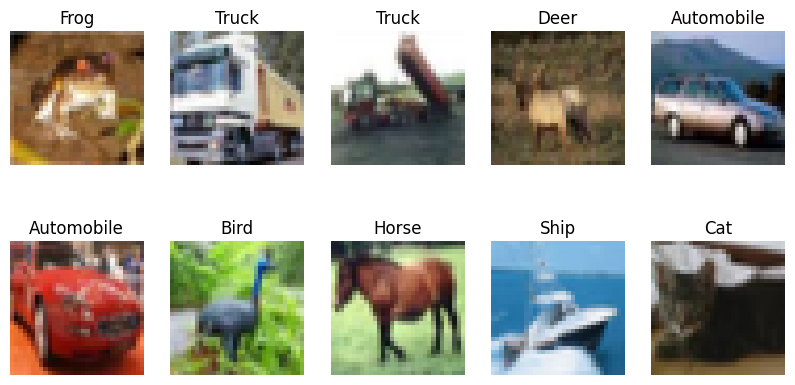

In [9]:
plt.figure(figsize=(10,5))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(X_train[i])

    plt.title(class_names[y_train[i][0]])

    plt.axis("off")

plt.show()

## Normalize Image Data

In [10]:
X_train = X_train / 255.0

X_test = X_test / 255.0

## Build CNN Model

In [11]:
model = tf.keras.models.Sequential()

model.add(tf.keras.layers.Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(32,32,3)
))

model.add(tf.keras.layers.MaxPooling2D((2,2)))

model.add(tf.keras.layers.Conv2D(
    64,
    (3,3),
    activation='relu'
))

model.add(tf.keras.layers.MaxPooling2D((2,2)))

model.add(tf.keras.layers.Flatten())

model.add(tf.keras.layers.Dense(
    64,
    activation='relu'
))

model.add(tf.keras.layers.Dense(
    10,
    activation='softmax'
))

c:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

## Train Model

In [13]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_data=(X_test,y_test)
)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.4901 - loss: 1.4204 - val_accuracy: 0.5918 - val_loss: 1.1543
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.6246 - loss: 1.0750 - val_accuracy: 0.6398 - val_loss: 1.0382
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.6696 - loss: 0.9480 - val_accuracy: 0.6749 - val_loss: 0.9455
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.7030 - loss: 0.8577 - val_accuracy: 0.6838 - val_loss: 0.9204
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.7266 - loss: 0.7861 - val_accuracy: 0.6898 - val_loss: 0.9003


## Evaluate Model

In [14]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy :", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6898 - loss: 0.9003
Test Accuracy : 0.6898000240325928


## Predict Image Class

In [15]:
prediction = model.predict(X_test)

predicted_class = np.argmax(prediction[0])

print("Predicted :", class_names[predicted_class])

print("Actual :", class_names[y_test[0][0]])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Predicted : Cat
Actual : Cat


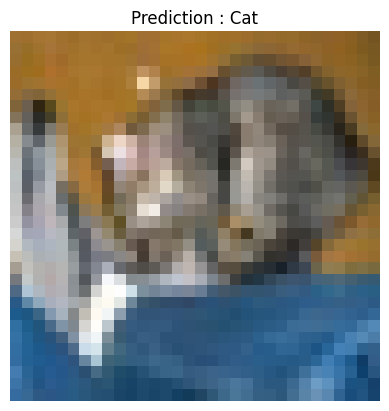

In [16]:
plt.imshow(X_test[0])

plt.title(
    f"Prediction : {class_names[predicted_class]}"
)

plt.axis("off")

plt.show()

## Save Model

In [17]:
model.save("model.h5")

print("Model Saved Successfully")

Model Saved Successfully


# Conclusion

The Image Classification model successfully classifies images into ten categories using Convolutional Neural Networks (CNN).

Technologies Used:

- TensorFlow
- Keras
- CNN
- Deep Learning

Dataset:

- CIFAR-10

This project demonstrates the application of deep learning in image recognition and classification tasks.